In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [33]:
df = pd.read_csv('higher_edu_std_perf_eval.csv')
df.head()

,Unnamed: 0,Scholarship Type,Weekly Study Hours,Midterm Preparation (When)
0,0,3,5,1
1,1,3,1,1
2,2,2,1,1
3,3,1,1,1
4,4,1,4,2


In [34]:
df = df.drop(columns=['Unnamed: 0'])

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 3 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Scholarship Type            145 non-null    int64
 1   Weekly Study Hours          145 non-null    int64
 2   Midterm Preparation (When)  145 non-null    int64
dtypes: int64(3)
memory usage: 3.5 KB


In [36]:
df.shape

(145, 3)

In [37]:
df.describe()

,Scholarship Type,Weekly Study Hours,Midterm Preparation (When)
count,145.000000,145.000000,145.000000
mean,1.944828,2.806897,1.337931
std,0.537216,1.329664,0.614870
min,1.000000,1.000000,1.000000
25%,2.000000,2.000000,1.000000
50%,2.000000,3.000000,1.000000
75%,2.000000,4.000000,2.000000
max,3.000000,5.000000,3.000000


In [38]:
df["Prep_encoded"] = df["Midterm Preparation (When)"].astype("category").cat.codes
df.head()

,Scholarship Type,Weekly Study Hours,Midterm Preparation (When),Prep_encoded
0,3,5,1,0
1,3,1,1,0
2,2,1,1,0
3,1,1,1,0
4,1,4,2,1


In [39]:
X = df[[
    "Weekly Study Hours",
    "Prep_encoded"
]]


In [40]:
df["Z_axis"] = 0

In [42]:
from sklearn.cluster import KMeans
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)


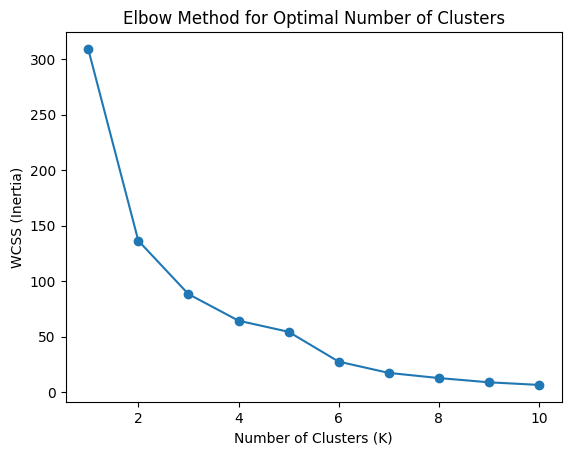

In [43]:
plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.show()


In [44]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
df["KMeans_Cluster"] = kmeans.fit_predict(X)


In [45]:
import plotly.express as px

fig = px.scatter_3d(
    df,
    x="Weekly Study Hours",
    y="Prep_encoded",
    z="Z_axis",
    color=df["KMeans_Cluster"].astype(str),
    title="K-Means Clustering (K = 4)",
    labels={
        "Weekly Study Hours": "Weekly Study Hours",
        "Prep_encoded": "Midterm Preparation (encoded)"
    }
)
fig.show()


In [46]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(n_clusters=4, linkage="ward")
df["Hierarchical_Cluster"] = hierarchical.fit_predict(X)


In [47]:
fig = px.scatter_3d(
    df,
    x="Weekly Study Hours",
    y="Prep_encoded",
    z="Z_axis",
    color=df["Hierarchical_Cluster"].astype(str),
    title="Hierarchical Clustering (4 Clusters)",
    labels={
        "Weekly Study Hours": "Weekly Study Hours",
        "Prep_encoded": "Midterm Preparation (encoded)"
    }
)
fig.show()


In [48]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.9, min_samples=2)
df["DBSCAN_Cluster"] = dbscan.fit_predict(X)


In [49]:
fig = px.scatter_3d(
    df,
    x="Weekly Study Hours",
    y="Prep_encoded",
    z="Z_axis",
    color=df["DBSCAN_Cluster"].astype(str),
    title="DBSCAN Clustering (Density-Based)",
    labels={
        "Weekly Study Hours": "Weekly Study Hours",
        "Prep_encoded": "Midterm Preparation (encoded)"
    }
)
fig.show()


In [50]:
from sklearn.metrics import silhouette_score

In [51]:
kmeans = KMeans(
    n_clusters=6,
    init="k-means++",
    n_init=20,
    random_state=42
)

labels = kmeans.fit_predict(X_scaled)
df["Final_Cluster"] = labels

print("K-Means++ Silhouette:", silhouette_score(X_scaled, labels))


NameError: name 'X_scaled' is not defined

In [52]:
import plotly.express as px

fig = px.scatter_3d(
    df,
    x="Weekly Study Hours",
    y="Prep_encoded",
    z="Z_axis",
    color=df["Final_Cluster"].astype(str),
    title="Final Clustering using K-Means++ (K = 6)"
)
fig.show()


KeyError: 'Final_Cluster'

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df["PC1"] = X_pca[:, 0]
df["PC2"] = X_pca[:, 1]


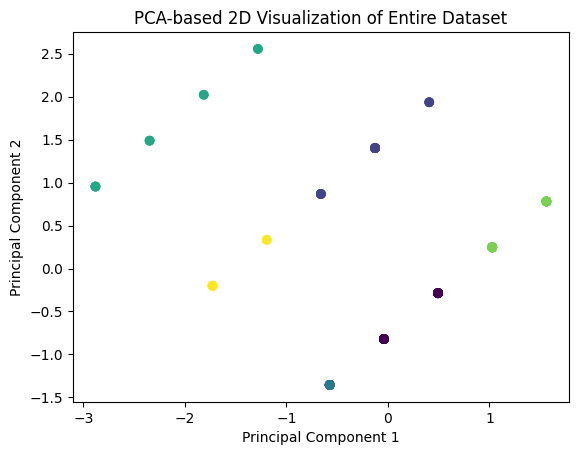

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(
    df["PC1"],
    df["PC2"],
    c=df["Final_Cluster"]
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA-based 2D Visualization of Entire Dataset")
plt.show()


In [53]:
# Save results for the Meta-Model
df.to_csv('performance_results.csv', index=False)
print("Performance results exported to performance_results.csv")

Performance results exported to performance_results.csv
